<a href="https://colab.research.google.com/github/sungmin-Jeon/financial_practice-/blob/main/notebooks/VAR%EC%8B%A4%EC%8A%B5(BTC_ETH).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [49]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.stattools import coint
from statsmodels.tsa.api import VAR

# 데이터(BTC, ETH 일봉) 수집

In [29]:
def get_all_data(market, total=1000):
    """
    Upbit API를 사용하여 지정한 코인의 일봉 데이터를 최대 total 개수까지 수집하는 함수

    Parameters:
    - market (str): 예) "KRW-BTC", "KRW-ETH"
    - total (int): 가져올 데이터 개수

    Returns:
    - pandas DataFrame: date, price 형태의 정리된 시계열 데이터
    """

    url = "https://api.upbit.com/v1/candles/days"

    all_df = []     # 각 요청에서 받은 데이터프레임을 저장
    to = None       # 과거 데이터 요청을 위한 기준 시점
    collected = 0   # 현재까지 수집한 데이터 개수

    # 원하는 개수만큼 데이터 수집
    while collected < total:

        params = {
            "market": market,
            "count": min(200, total - collected)  # 최대 200개 제한
        }

        # 첫 요청 이후에는 'to'를 사용하여 더 과거 데이터 요청
        if to is not None:
            params["to"] = to

        response = requests.get(url, params=params)
        data = response.json()

        # 응답이 비정상인 경우 종료
        if not isinstance(data, list) or len(data) == 0:
            break

        df = pd.DataFrame(data)
        all_df.append(df)

        # 수집된 데이터 개수 업데이트
        collected += len(df)

        # 다음 요청을 위해 가장 오래된 시점 저장 (pagination 역할)
        to = df["candle_date_time_utc"].iloc[-1]

    # 데이터가 하나도 없을 경우 빈 DataFrame 반환
    if not all_df:
        return pd.DataFrame(columns=["date", market.split("-")[1].lower()])

    # 여러 번 나눠 받은 데이터를 하나로 합침
    df = pd.concat(all_df, ignore_index=True)

    # 분석에 필요한 컬럼만 선택
    df = df[["candle_date_time_kst", "trade_price"]]

    # 컬럼명 정리 (예: btc, eth)
    df.columns = ["date", market.split("-")[1].lower()]

    # 날짜 형식 변환
    df["date"] = pd.to_datetime(df["date"])

    # 중복 제거 및 시간순 정렬
    df = df.drop_duplicates(subset="date")
    df = df.sort_values("date").reset_index(drop=True)

    return df

In [31]:
btc = get_all_data("KRW-BTC")
eth = get_all_data("KRW-ETH")

df = pd.merge(btc, eth, on='date')
df['log_btc'] = np.log(df['btc'])
df['log_eth'] = np.log(df['eth'])

df.head()

,date,btc,eth,log_btc,log_eth
0,2023-07-29 09:00:00,37901000.0,2426000.0,17.450488,14.701754
1,2023-07-30 09:00:00,37850000.0,2409000.0,17.449142,14.694722
2,2023-07-31 09:00:00,37929000.0,2409000.0,17.451227,14.694722
3,2023-08-01 09:00:00,38642000.0,2437000.0,17.469850,14.706278
4,2023-08-02 09:00:00,38358000.0,2420000.0,17.462474,14.699278


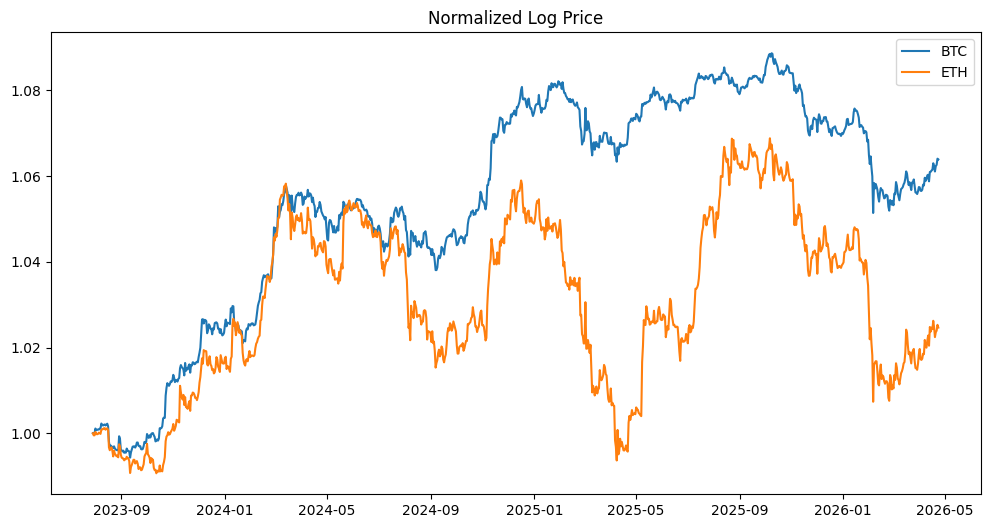

In [34]:
df['norm_btc'] = df['log_btc'] / df['log_btc'].iloc[0]
df['norm_eth'] = df['log_eth'] / df['log_eth'].iloc[0]

plt.figure(figsize=(12,6))
plt.plot(df['date'], df['norm_btc'], label='BTC')
plt.plot(df['date'], df['norm_eth'], label='ETH')
plt.legend()
plt.title('Normalized Log Price')
plt.show()

# ADF , 공적분 검정

## 정상성 검정

In [37]:
def adf_test(series, name='Series'):
    result = adfuller(series.dropna())

    print(f'ADF Statistic : {result[0]:.6f}')
    print(f'p-value       : {result[1]:.6f}')
    print(f'Lags Used     : {result[2]}')
    print(f'N Observations: {result[3]}')

    print('Critical Values:')
    for key, value in result[4].items():
        print(f'   {key}: {value:.6f}')

    if result[1] < 0.05:
        print('=> 귀무가설 기각: 정상시계열로 볼 수 있음')
    else:
        print('=> 귀무가설 기각 불가: 비정상시계열로 볼 수 있음')
    print()

adf_test(df['log_btc'], 'log_btc')
adf_test(df['log_eth'], 'log_eth')

ADF Statistic : -2.213753
p-value       : 0.201292
Lags Used     : 2
N Observations: 997
Critical Values:
   1%: -3.436926
   5%: -2.864443
   10%: -2.568316
=> 귀무가설 기각 불가: 비정상시계열로 볼 수 있음

ADF Statistic : -2.006683
p-value       : 0.283651
Lags Used     : 0
N Observations: 999
Critical Values:
   1%: -3.436913
   5%: -2.864437
   10%: -2.568313
=> 귀무가설 기각 불가: 비정상시계열로 볼 수 있음



In [38]:
# 차분 후 ADF 검정
df['d_log_btc'] = df['log_btc'].diff()
df['d_log_eth'] = df['log_eth'].diff()

adf_test(df['d_log_btc'], 'd_log_btc')
adf_test(df['d_log_eth'], 'd_log_eth')

ADF Statistic : -21.505618
p-value       : 0.000000
Lags Used     : 1
N Observations: 997
Critical Values:
   1%: -3.436926
   5%: -2.864443
   10%: -2.568316
=> 귀무가설 기각: 정상시계열로 볼 수 있음

ADF Statistic : -31.737065
p-value       : 0.000000
Lags Used     : 0
N Observations: 998
Critical Values:
   1%: -3.436919
   5%: -2.864440
   10%: -2.568314
=> 귀무가설 기각: 정상시계열로 볼 수 있음



## 공적분 검정
BTC와 ETH는 시각적으로는 유사한 움직임을 보이나, 공적분 검정 결과 장기균형 관계는 확인되지 않았다. 따라서 두 시계열 간에는 고정된 선형관계가 존재하지 않으며, 차분된 series를 이용한 VAR 모형을 적용하는 것이 적절하다.

In [41]:
score, pvalue, crit = coint(df['log_btc'], df['log_eth'])

print('===== Cointegration Test: log_btc vs log_eth =====')
print(f'Test Statistic: {score:.6f}')
print(f'p-value       : {pvalue:.6f}')
print('Critical Values:')
print(f'   1% : {crit[0]:.6f}')
print(f'   5% : {crit[1]:.6f}')
print(f'   10%: {crit[2]:.6f}')

if pvalue < 0.05:
    print('=> 귀무가설 기각: 공적분 관계가 있다고 볼 수 있음')
else:
    print('=> 귀무가설 기각 불가: 공적분 관계가 없다고 볼 수 있음')

===== Cointegration Test: log_btc vs log_eth =====
Test Statistic: -1.484385
p-value       : 0.767131
Critical Values:
   1% : -3.907436
   5% : -3.342253
   10%: -3.048698
=> 귀무가설 기각 불가: 공적분 관계가 없다고 볼 수 있음


# 차분 VAR 적용

In [48]:
# 차분 데이터 준비 및 정상성 재확
var_df = df[['d_log_btc', 'd_log_eth']].dropna().copy()
display(var_df.head())

adf_test(var_df['d_log_btc'], 'd_log_btc')
adf_test(var_df['d_log_eth'], 'd_log_eth')

,d_log_btc,d_log_eth
1,-0.001347,-0.007032
2,0.002085,0.000000
3,0.018624,0.011556
4,-0.007377,-0.007000
5,0.002031,-0.000827


ADF Statistic : -21.505618
p-value       : 0.000000
Lags Used     : 1
N Observations: 997
Critical Values:
   1%: -3.436926
   5%: -2.864443
   10%: -2.568316
=> 귀무가설 기각: 정상시계열로 볼 수 있음

ADF Statistic : -31.737065
p-value       : 0.000000
Lags Used     : 0
N Observations: 998
Critical Values:
   1%: -3.436919
   5%: -2.864440
   10%: -2.568314
=> 귀무가설 기각: 정상시계열로 볼 수 있음



In [50]:
# 적정 lag 선택
model = VAR(var_df)
lag_order_results = model.select_order(maxlags=10)

print(lag_order_results.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0      -15.41*     -15.40*  2.025e-07*     -15.41*
1       -15.41      -15.38   2.027e-07      -15.40
2       -15.41      -15.36   2.031e-07      -15.39
3       -15.41      -15.34   2.040e-07      -15.38
4       -15.40      -15.31   2.051e-07      -15.37
5       -15.40      -15.29   2.057e-07      -15.36
6       -15.39      -15.26   2.065e-07      -15.34
7       -15.39      -15.24   2.069e-07      -15.33
8       -15.38      -15.22   2.083e-07      -15.32
9       -15.38      -15.19   2.097e-07      -15.31
10      -15.37      -15.16   2.107e-07      -15.29
--------------------------------------------------


## 적정 lag 선택 결과

차분된 시계열 `d_log_btc`와 `d_log_eth`를 이용해 VAR 모형의 적정 시차를 선택하였다.  
정보기준(AIC, BIC, HQIC)을 확인한 결과, 모두 **lag = 0**을 최적 시차로 선택하였다.

이는 과거 시점의 `d_log_btc`, `d_log_eth` 값을 추가하더라도 현재 시점의 값을 예측하는 데 유의한 개선이 없음을 의미한다.  
즉, 차분된 BTC와 ETH 시계열 사이에는 VAR 모형으로 설명할 만한 뚜렷한 단기 동태적 관계가 크지 않다고 해석할 수 있다.

따라서 본 사례에서는 차분 후 VAR 모형을 추가적으로 적합하더라도 해석할 만한 구조가 제한적이라고 판단하였다.

## 최종 해석

BTC와 ETH는 시각적으로 유사한 움직임을 보이지만, 공적분 검정 결과 장기균형 관계는 확인되지 않았다. 또한 차분 후 VAR 모형의 적정 시차가 0으로 선택되어 단기적인 동태적 상호작용 또한 뚜렷하지 않은 것으로 나타났다. 따라서 두 시계열 간에는 통계적으로 유의한 장기 및 단기 관계가 제한적이라고 해석할 수 있다.